# 第 11 章 · TD(0) 代码实验

[章节网页](../ch11.html)

## 运行内容

- 执行 bootstrap 更新
- 输出 TD target
- 绘制状态价值

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备一个学习路径 MDP：状态、动作、转移概率和即时奖励。
states = ["S0", "S1", "S2", "S3"]
actions = {
    "S0": ["刷题", "看讲解"],
    "S1": ["复盘", "继续"],
    "S2": ["测验"],
    "S3": [],
}
transitions = {
    ("S0", "刷题"): [("S1", 0.75, 1.0), ("S0", 0.25, -0.2)],
    ("S0", "看讲解"): [("S1", 0.55, 0.6), ("S0", 0.45, 0.0)],
    ("S1", "复盘"): [("S2", 0.80, 1.2), ("S1", 0.20, 0.0)],
    ("S1", "继续"): [("S2", 0.60, 0.7), ("S1", 0.40, -0.1)],
    ("S2", "测验"): [("S3", 1.00, 2.0)],
}

display(pd.DataFrame(
    [
        {"状态": s, "动作": a, "转移": transitions[(s, a)]}
        for s, acts in actions.items()
        for a in acts
    ]
))

,状态,动作,转移
0,S0,刷题,"[(S1, 0.75, 1.0), (S0, 0.25, -0.2)]"
1,S0,看讲解,"[(S1, 0.55, 0.6), (S0, 0.45, 0.0)]"
2,S1,复盘,"[(S2, 0.8, 1.2), (S1, 0.2, 0.0)]"
3,S1,继续,"[(S2, 0.6, 0.7), (S1, 0.4, -0.1)]"
4,S2,测验,"[(S3, 1.0, 2.0)]"


## 1. TD 更新

In [3]:
# TD(0)：用下一状态价值修正当前状态价值。
trajectory = [
    ("S0", 0.0, "S1"),
    ("S1", 1.0, "S2"),
    ("S2", 2.0, "S3"),
    ("S0", 0.5, "S1"),
    ("S1", 1.2, "S2"),
]
V_td = defaultdict(float)
alpha = 0.4
gamma = 0.9
td_rows = []

for step, (state, reward, next_state) in enumerate(trajectory, start=1):
    target = reward + gamma * V_td[next_state]
    old = V_td[state]
    V_td[state] = old + alpha * (target - old)
    td_rows.append({
        "步": step,
        "状态": state,
        "奖励": reward,
        "下一状态": next_state,
        "TD target": round(target, 3),
        "更新后V": round(V_td[state], 3),
    })

td_trace = pd.DataFrame(td_rows)
display(td_trace)

,步,状态,奖励,下一状态,TD target,更新后V
0,1,S0,0.0,S1,0.00,0.000
1,2,S1,1.0,S2,1.00,0.400
2,3,S2,2.0,S3,2.00,0.800
3,4,S0,0.5,S1,0.86,0.344
4,5,S1,1.2,S2,1.92,1.008


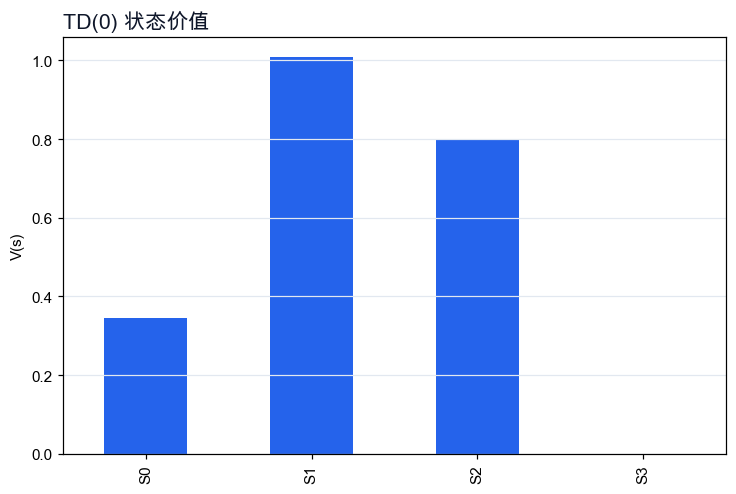

In [4]:
# 绘制 TD 更新后的状态价值。
fig, ax = plt.subplots(figsize=(6.8, 4.6))
td_values = pd.Series({state: V_td[state] for state in states})
td_values.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("TD(0) 状态价值", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_ylabel("V(s)")
ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()